# SR-only diagnostic plots (thermoift style)

Uses `thermoift.MLPostprocessing` so the SR parity / residual plots match the rest of the project (GPR, SVGP).

For each available target the notebook produces:
- **Parity plot** (`plot_parity`) — gray Train / lightblue Test / red Validation, per-split R² in the legend, dashed `y = x`.
- **Residual-vs-predicted plot** (`plot_residual_vs_predicted`) — same split colours, zero-residual line and ±RMSE bands per split.

Targets:
- `gamma` — reconstructed γ_cDFT  (mN m⁻¹) — needs `gamma_cDFT_*` or `gamma_base` columns in the CSVs.
- `delta_gamma` — Δγ = γ_cDFT − γ_base  (mN m⁻¹) — same column requirement.
- `eps_base` — the SR's direct dimensionless target  (always available).

**Reads:** `SR_MIXTURES_OUTPUTS/SR_{train,validation,test}_predictions_eps_base.csv`
**Writes:** `SR_MIXTURES_OUTPUTS/SR_parity_<target>.{png,pdf}` and `SR_MIXTURES_OUTPUTS/SR_residual_<target>.{png,pdf}` for each target.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from thermoift import MLPostprocessing

## Config

Toggle `TARGET_MODE` to `"eps_base"` if you'd rather plot the SR's direct dimensionless target.

In [2]:
# Targets to plot — any subset of {"gamma", "delta_gamma", "eps_base"}.
# Targets needing reconstructed γ_cDFT will silently skip if the CSVs lack the required columns.
TARGETS = ["gamma", "delta_gamma", "eps_base"]

In [3]:
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

OUT_DIR = HERE / "SR_MIXTURES_OUTPUTS_V2"
CSV_PATHS = {
    "train": OUT_DIR / "SR_train_predictions_eps_base.csv",
    "val":   OUT_DIR / "SR_validation_predictions_eps_base.csv",
    "test":  OUT_DIR / "SR_test_predictions_eps_base.csv",
}

# Source dataset used by Mixture.jl. Required only if the prediction CSVs
# lack gamma_base / gamma_cDFT_* columns and we need to recover γ_base.
SOURCE_CSV = HERE / "../../CombinedDatasetSEC_A4.csv"

## Helpers

Styling is provided by `thermoift.PLOT_SETTINGS` via `MLPostprocessing` — no manual rcParams needed here.

In [4]:
# thermoift.MLPostprocessing internally calls thermoift.PLOT_SETTINGS.plot_init(),
# which sets the IEEE matplotlib style + LaTeX rendering for every figure it creates.
# Nothing to configure here.

In [5]:
# Split colours come from thermoift.SPLIT_COLORS — used internally by
# MLPostprocessing.plot_parity / plot_residual_vs_predicted.

In [6]:
def rmse(a, p):
    return float(np.sqrt(np.mean((a - p) ** 2)))

def r2(a, p):
    a = np.asarray(a); p = np.asarray(p)
    ss_res = np.sum((a - p) ** 2)
    ss_tot = np.sum((a - np.mean(a)) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

## Load predictions and pick target columns

In [7]:
def build_gamma_base_lookup(source_path):
    """
    Read the source dataset, compute ε_base for every row, and return a dict
    mapping ε_base (as exact Float64) -> γ_base. Used to recover γ_base when
    the prediction CSVs only contain Actual / Predicted columns.
    """
    src = pd.read_csv(source_path)
    gb  = src["gamma_wsd_UC"].to_numpy(dtype=np.float64)
    gc  = (src["gamma_wsd_UC"] + src["gamma_cDFT_minus_wsd_uncorrected"]).to_numpy(dtype=np.float64)
    eps = (gc - gb) / gb
    ok  = np.isfinite(eps) & np.isfinite(gb) & (gb != 0.0)
    eps, gb = eps[ok], gb[ok]

    lookup, dupes = {}, 0
    for k, g in zip(eps.tolist(), gb.tolist()):
        if k in lookup and not np.isclose(lookup[k], g, rtol=1e-9):
            dupes += 1
        else:
            lookup[k] = g
    if dupes:
        print(f"WARN  {dupes} ambiguous ε_base values in source CSV (different γ_base) — first match kept.")
    return lookup


def recover_gamma_base(eps_values, lookup):
    """Look up γ_base for each ε_base value; unmatched entries are NaN."""
    return np.array([lookup.get(float(v), np.nan) for v in eps_values], dtype=np.float64)


def load_all_targets(csv_paths):
    """
    Returns data[target][split] = (actual, predicted) for each available target
    in {"gamma", "delta_gamma", "eps_base"}.

    γ_base is sourced in priority order:
      1. `gamma_base` column in the prediction CSV (new Mixture.jl runs)
      2. derived from `gamma_cDFT_actual` / (1 + Actual)
      3. looked up from SOURCE_CSV by matching ε_base values
    """
    out = {"gamma": {}, "delta_gamma": {}, "eps_base": {}}

    # Decide whether we need the source-CSV lookup
    need_lookup = False
    for path in csv_paths.values():
        cols = set(pd.read_csv(path, nrows=0).columns)
        if not (cols & {"gamma_base", "gamma_cDFT_actual"}):
            need_lookup = True
            break

    lookup = None
    if need_lookup:
        if SOURCE_CSV.exists():
            print(f"Building γ_base lookup from {SOURCE_CSV.name} ...")
            lookup = build_gamma_base_lookup(SOURCE_CSV)
        else:
            print(f"WARN  source CSV not found at {SOURCE_CSV}; γ / Δγ will be unavailable.")

    for split, path in csv_paths.items():
        df    = pd.read_csv(path)
        eps_a = df["Actual"].to_numpy(dtype=np.float64)
        eps_p = df["Predicted"].to_numpy(dtype=np.float64)
        out["eps_base"][split] = (eps_a, eps_p)

        # Try to obtain γ_base for this split
        gb = None
        if "gamma_base" in df.columns:
            gb = df["gamma_base"].to_numpy(dtype=np.float64)
        elif "gamma_cDFT_actual" in df.columns:
            gb = df["gamma_cDFT_actual"].to_numpy(dtype=np.float64) / (1.0 + eps_a)
        elif lookup is not None:
            gb = recover_gamma_base(eps_a, lookup)
        if gb is None:
            continue

        keep = np.isfinite(gb)
        n_miss = int((~keep).sum())
        if n_miss:
            print(f"WARN  {split}: {n_miss}/{len(gb)} rows had no source-CSV match — dropped from γ/Δγ.")
        if keep.sum() == 0:
            continue
        gb_k, eps_a_k, eps_p_k = gb[keep], eps_a[keep], eps_p[keep]

        # γ_cDFT — direct columns if available, else reconstruct
        if {"gamma_cDFT_actual", "gamma_cDFT_pred"}.issubset(df.columns):
            g_a = df["gamma_cDFT_actual"].to_numpy(dtype=np.float64)[keep]
            g_p = df["gamma_cDFT_pred"].to_numpy(dtype=np.float64)[keep]
        else:
            g_a = gb_k * (1.0 + eps_a_k)
            g_p = gb_k * (1.0 + eps_p_k)

        out["gamma"][split]       = (g_a, g_p)
        out["delta_gamma"][split] = (gb_k * eps_a_k, gb_k * eps_p_k)

    # Keep only targets that are complete across all splits
    needed = set(csv_paths.keys())
    available = {tgt: ps for tgt, ps in out.items() if set(ps.keys()) == needed}
    for tgt, ps in out.items():
        if tgt not in available and ps:
            print(f"WARN  '{tgt}' incomplete; skipped.")
    return available


def make_plots(target_key, target_data):
    """Build a MLPostprocessing and emit parity + residual plots for one target."""
    thermoift_target = {
        "gamma":       "gamma",
        "delta_gamma": "delta_gamma",
        "eps_base":    "delta_gamma",   # placeholder; labels overridden below
    }[target_key]

    post = MLPostprocessing(
        y_true=target_data["test"][0],
        y_pred=target_data["test"][1],
        target=thermoift_target,
        datasets={k: target_data[k] for k in ("train", "test", "val")},
    )
    if target_key == "eps_base":
        post._get_target_label  = lambda: r"$\varepsilon_{\mathrm{base}}$ / $[-]$"
        post._get_target_symbol = lambda: r"\varepsilon_{\mathrm{base}}"

    print(f"\n=== {target_key} : parity ===")
    post.plot_parity(
        save_path=f"SR_parity_{target_key}",
        folder=str(OUT_DIR),
    )
    print(f"=== {target_key} : residual ===")
    post.plot_residual_vs_predicted(
        save_path=f"SR_residual_{target_key}",
        folder=str(OUT_DIR),
    )
    print(f"Saved: SR_parity_{target_key}.(png|pdf), SR_residual_{target_key}.(png|pdf) in {OUT_DIR}")


data_all = load_all_targets(CSV_PATHS)
TARGETS_ACTUAL = [t for t in TARGETS if t in data_all]
print(f"\nTargets to plot: {TARGETS_ACTUAL}")


Targets to plot: ['gamma', 'delta_gamma', 'eps_base']


## γ (reconstructed γ_cDFT) — parity + residual

Requires the new CSV columns from `Mixture.jl` (`gamma_cDFT_actual` / `gamma_cDFT_pred`, or `gamma_base` to reconstruct). If missing, this cell prints a skip message.


=== gamma : parity ===


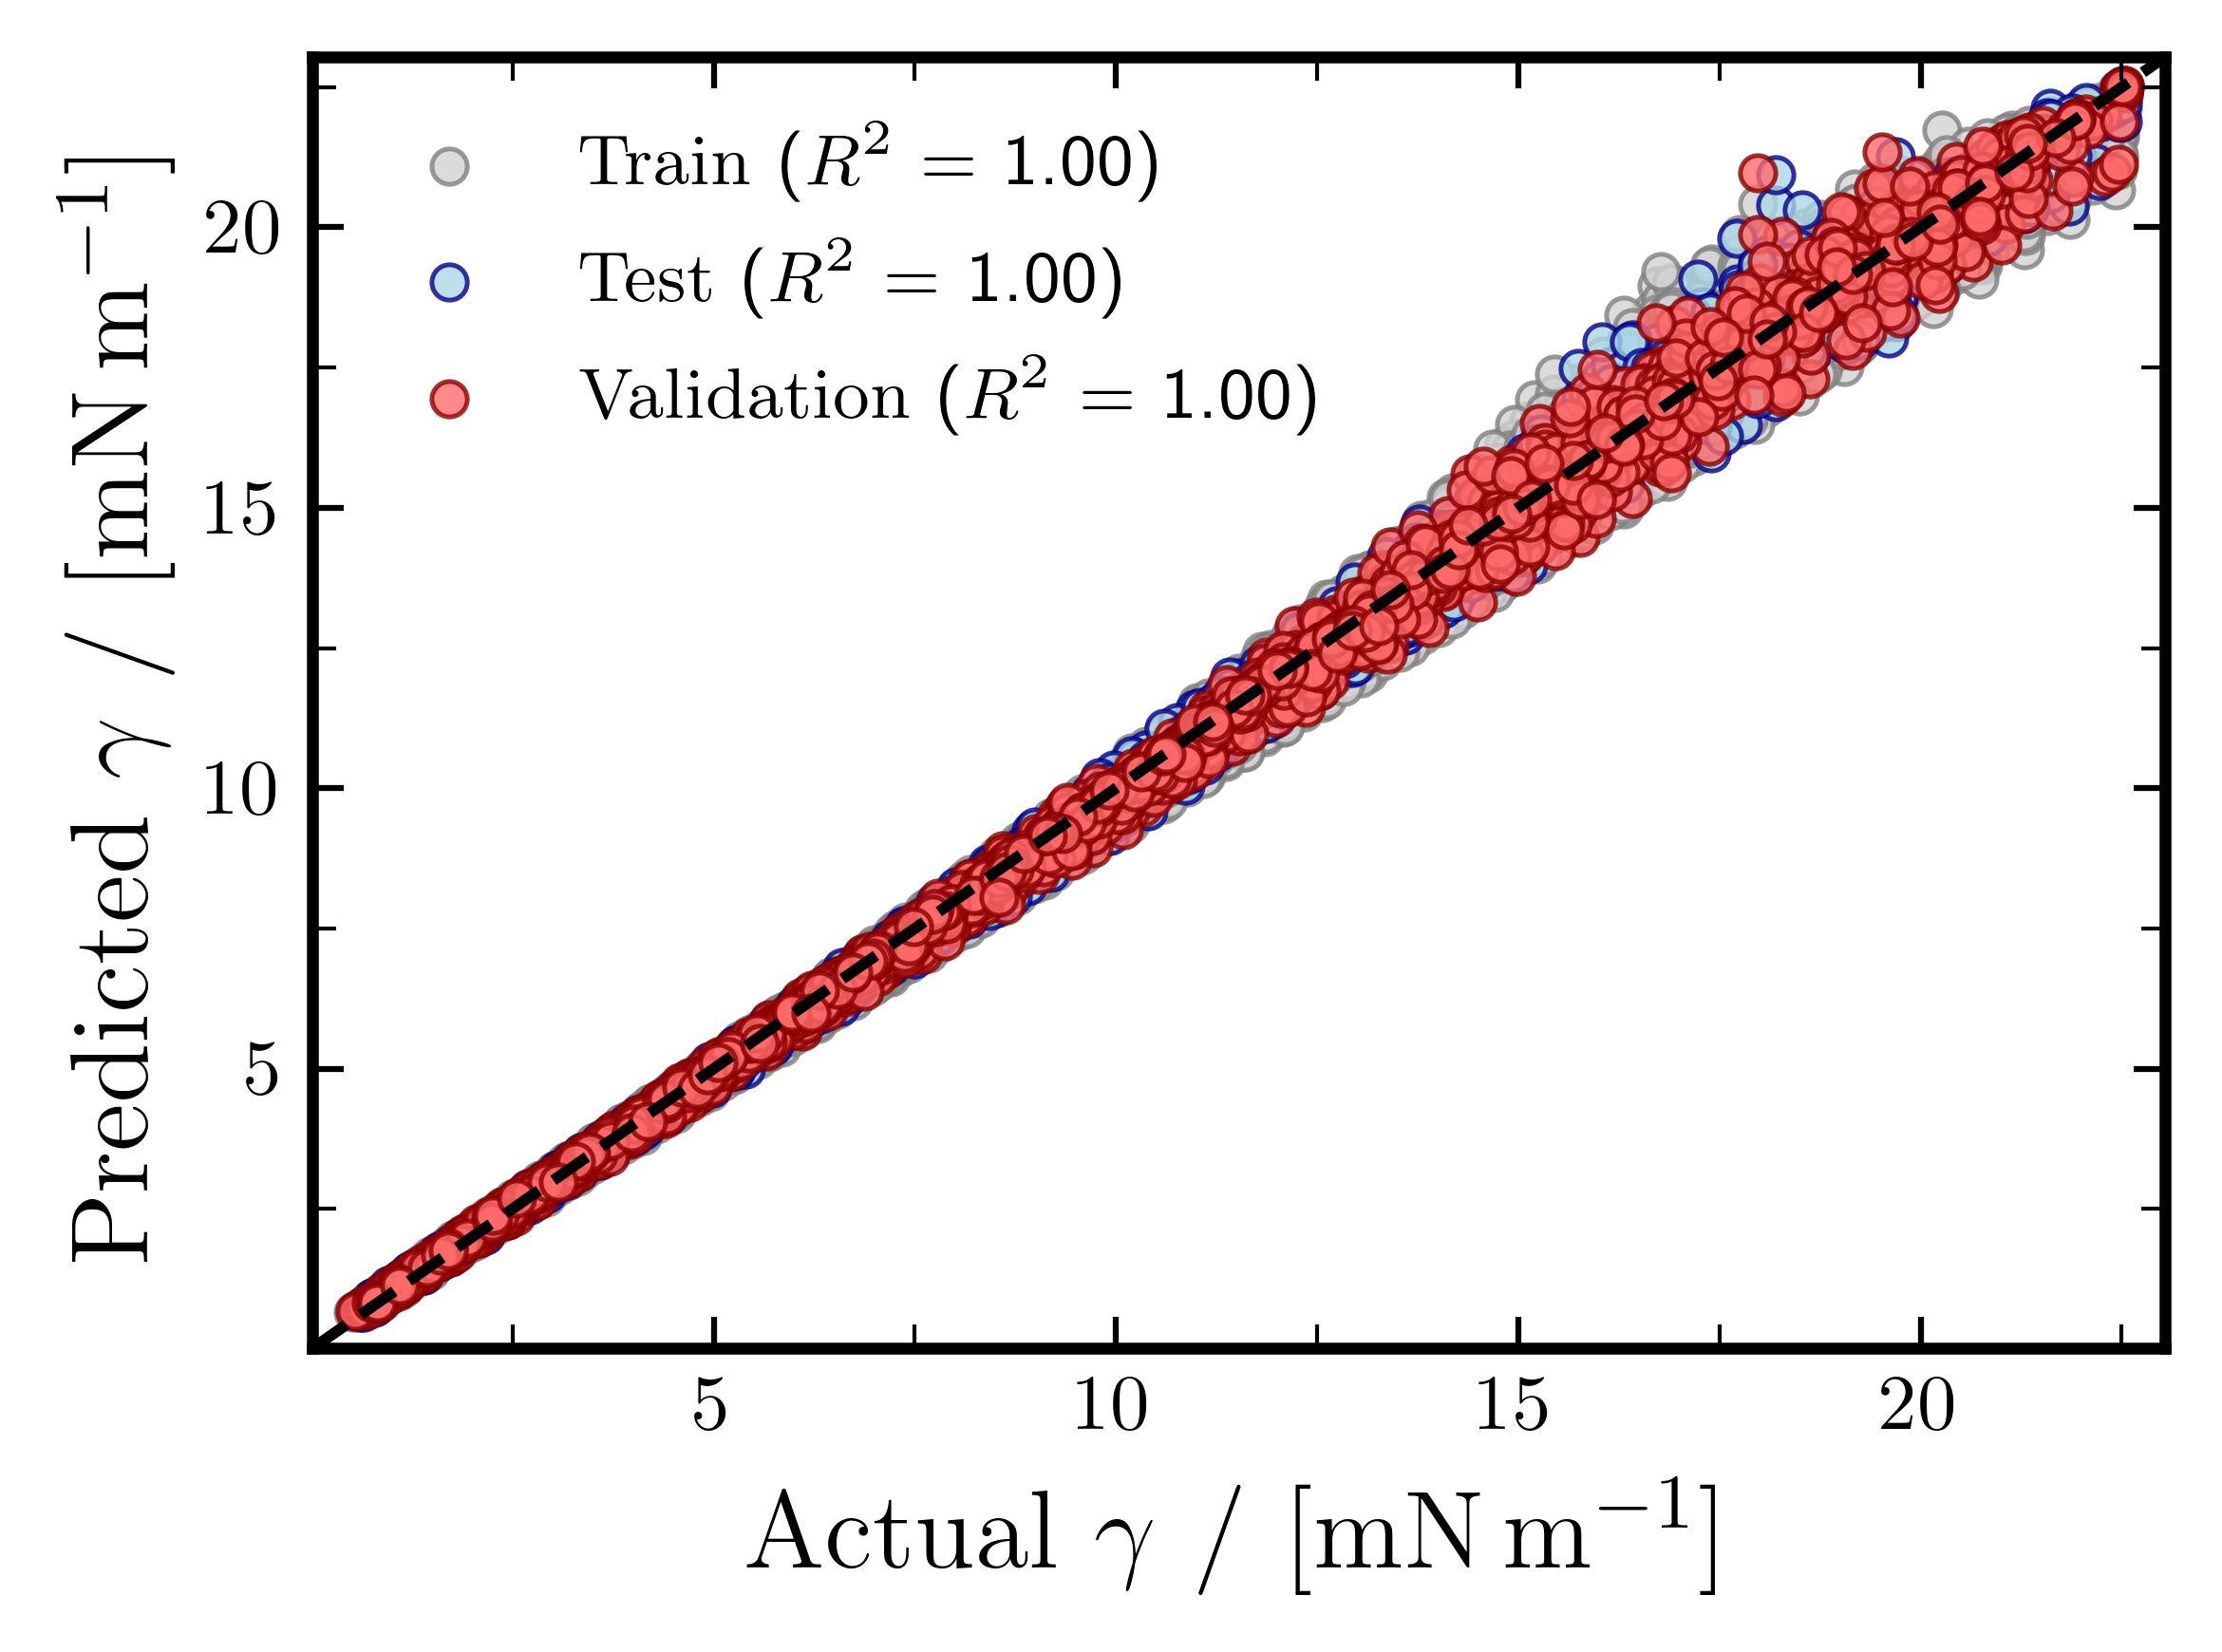

=== gamma : residual ===


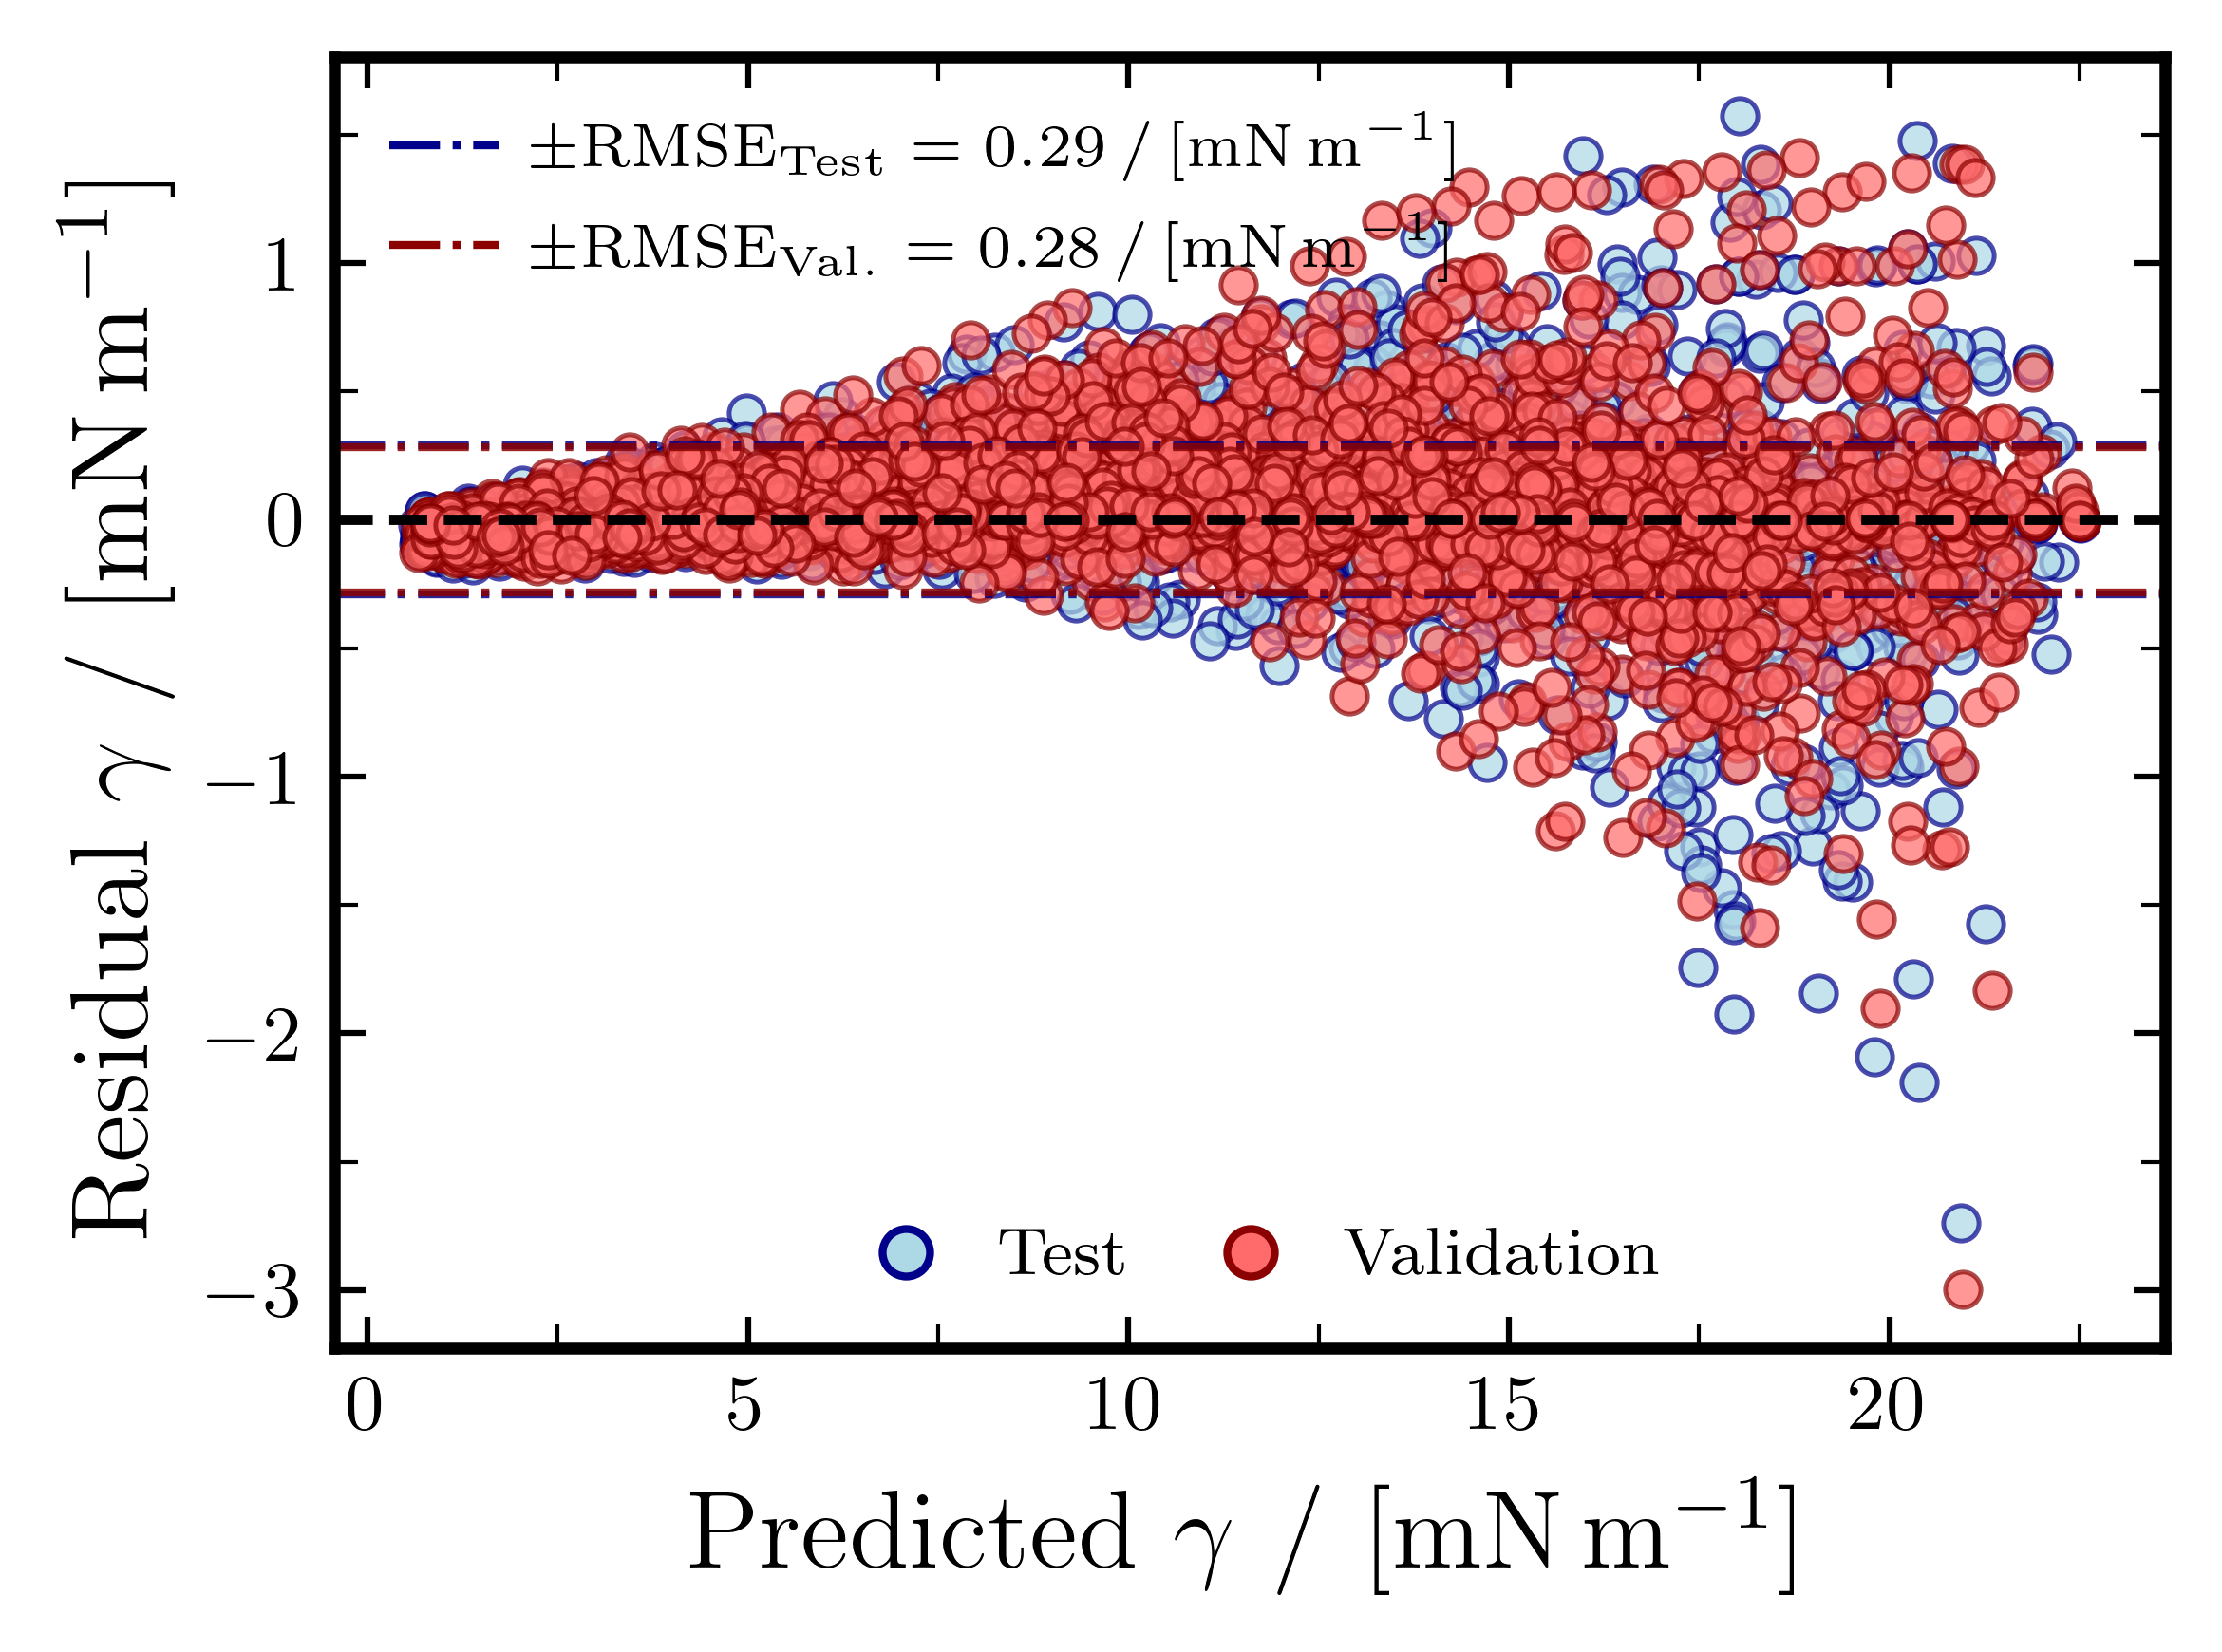

Saved: SR_parity_gamma.(png|pdf), SR_residual_gamma.(png|pdf) in /home/darshan/A6/PCSAFT_cDFT/PART_1/RESIDUAL/SR/Mixtures/SR_MIXTURES_OUTPUTS_V2


In [8]:
if "gamma" in data_all:
    make_plots("gamma", data_all["gamma"])
else:
    print("Skipped: 'gamma' target unavailable in current CSVs.")

## Δγ (γ_cDFT − γ_base) — parity + residual

Same data requirement as γ. Δγ is the physical residual the SR is implicitly modelling (ε_base × γ_base).


=== delta_gamma : parity ===


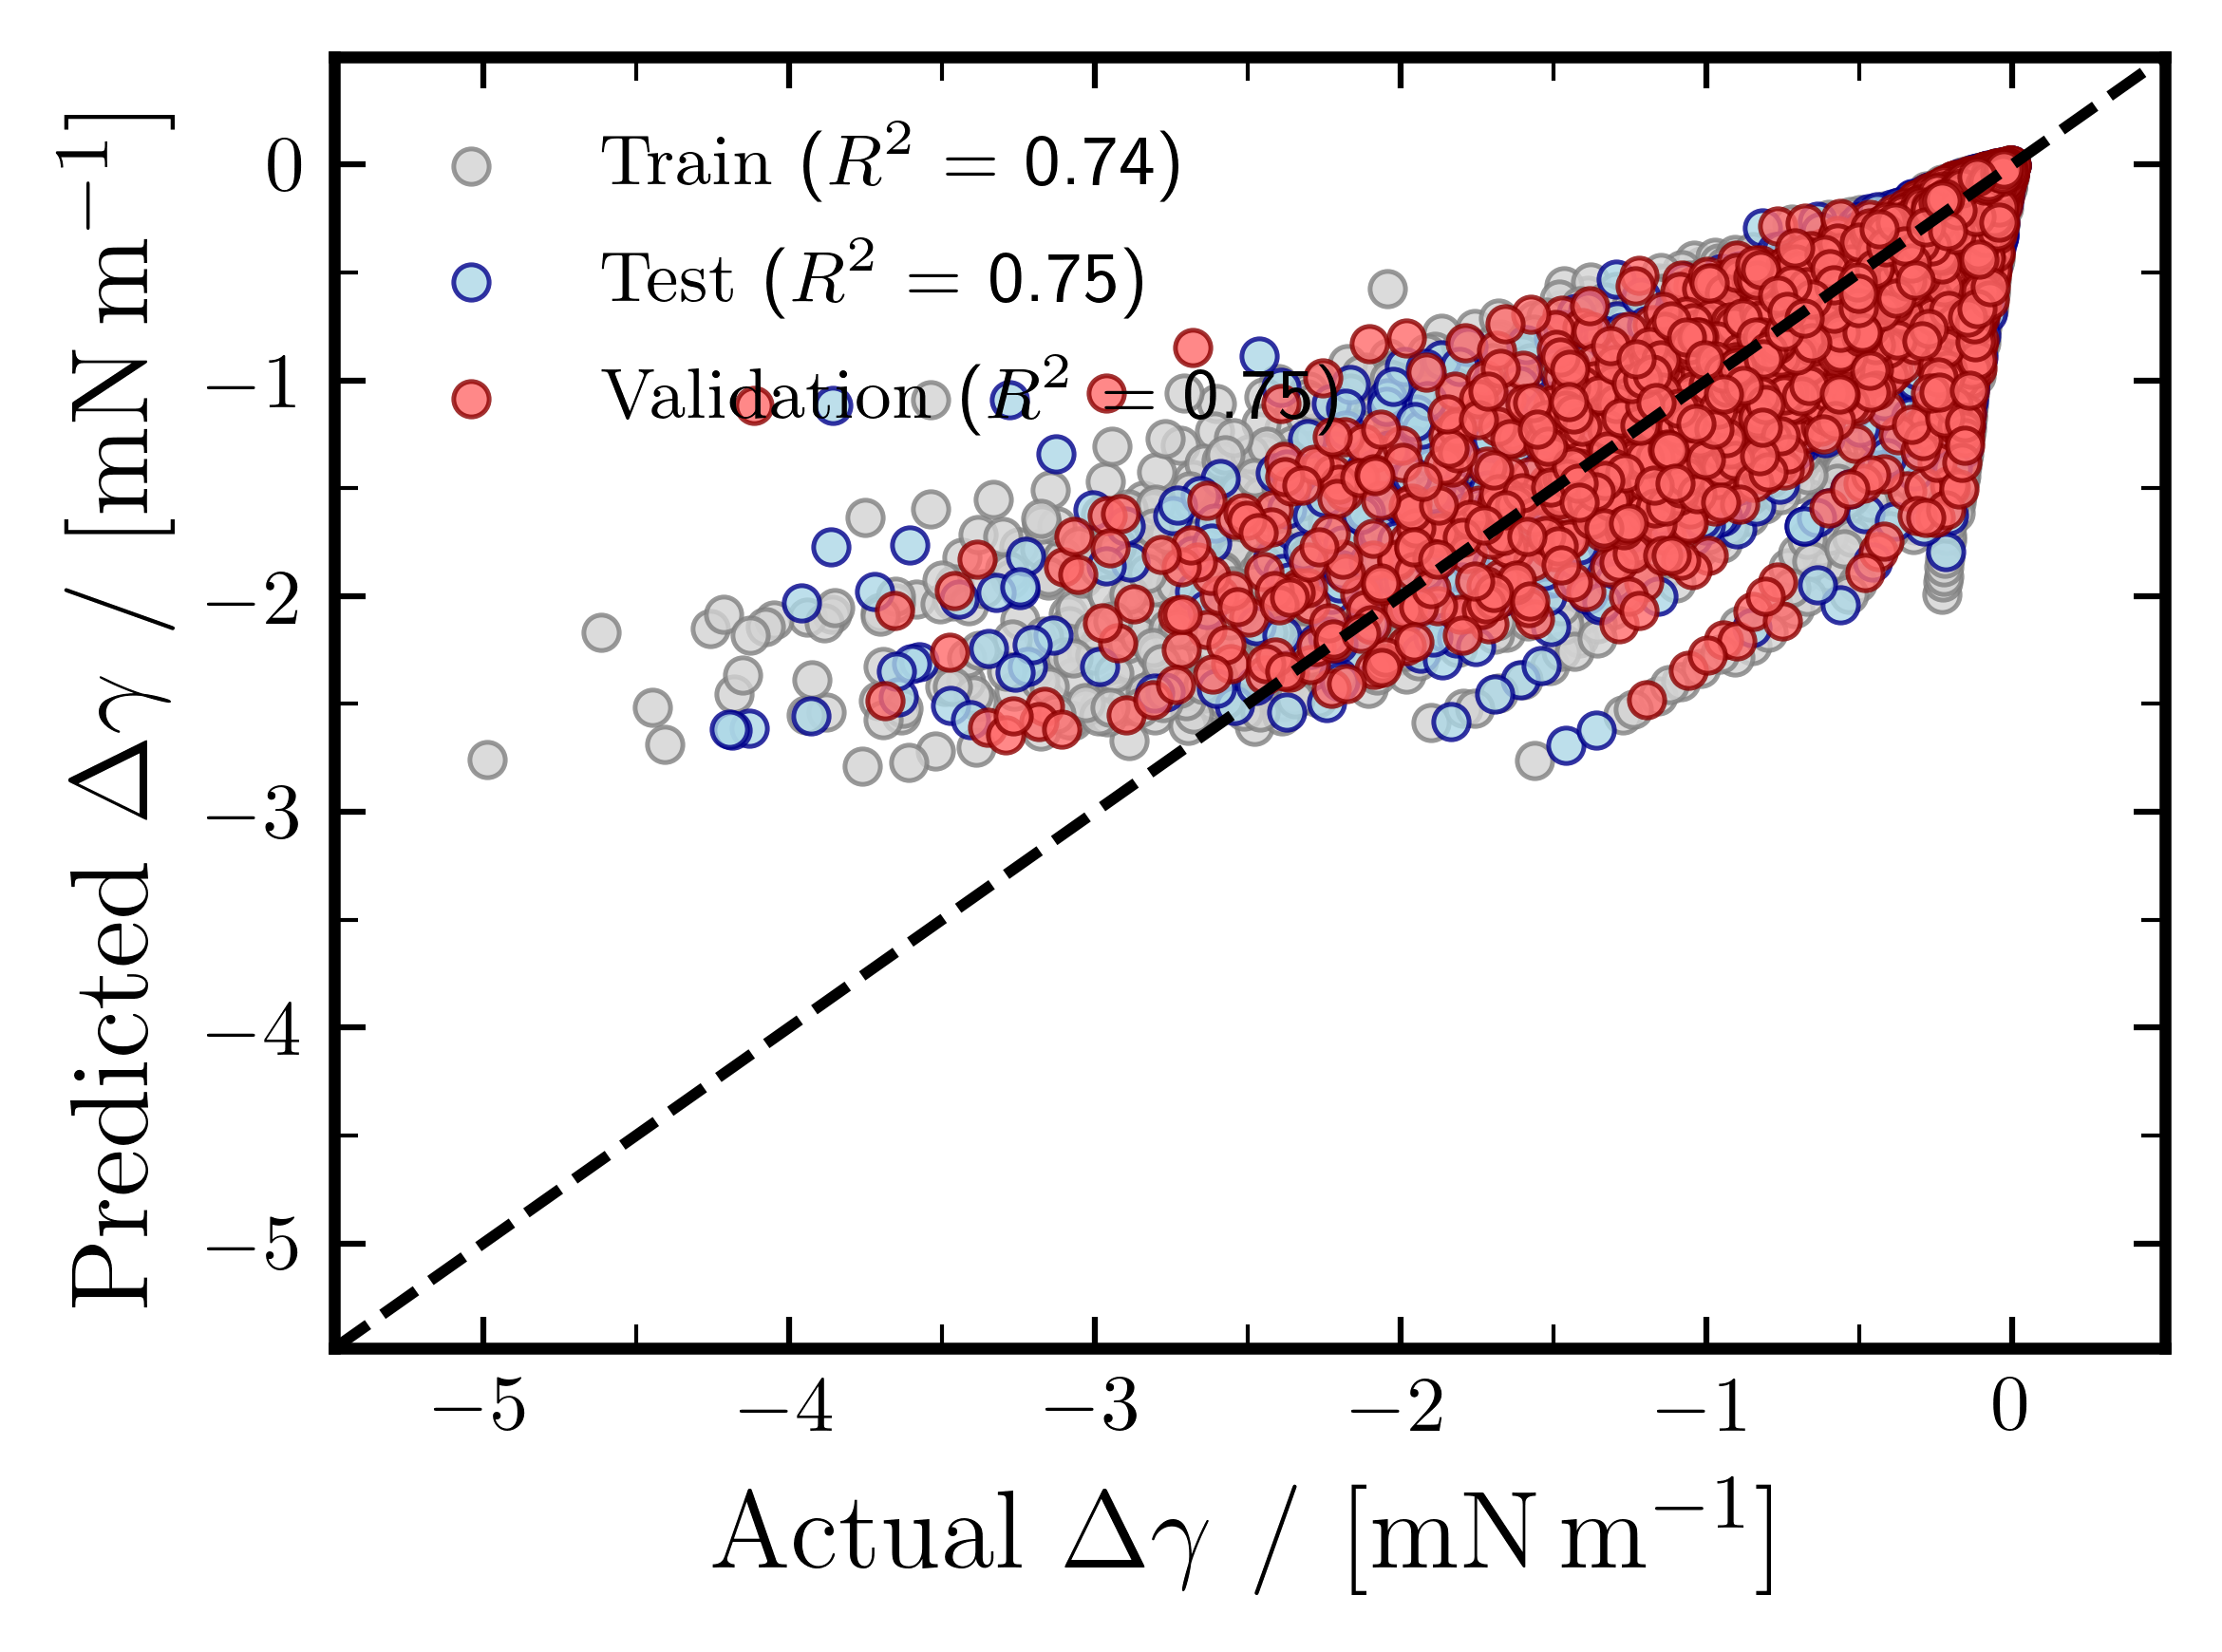

=== delta_gamma : residual ===


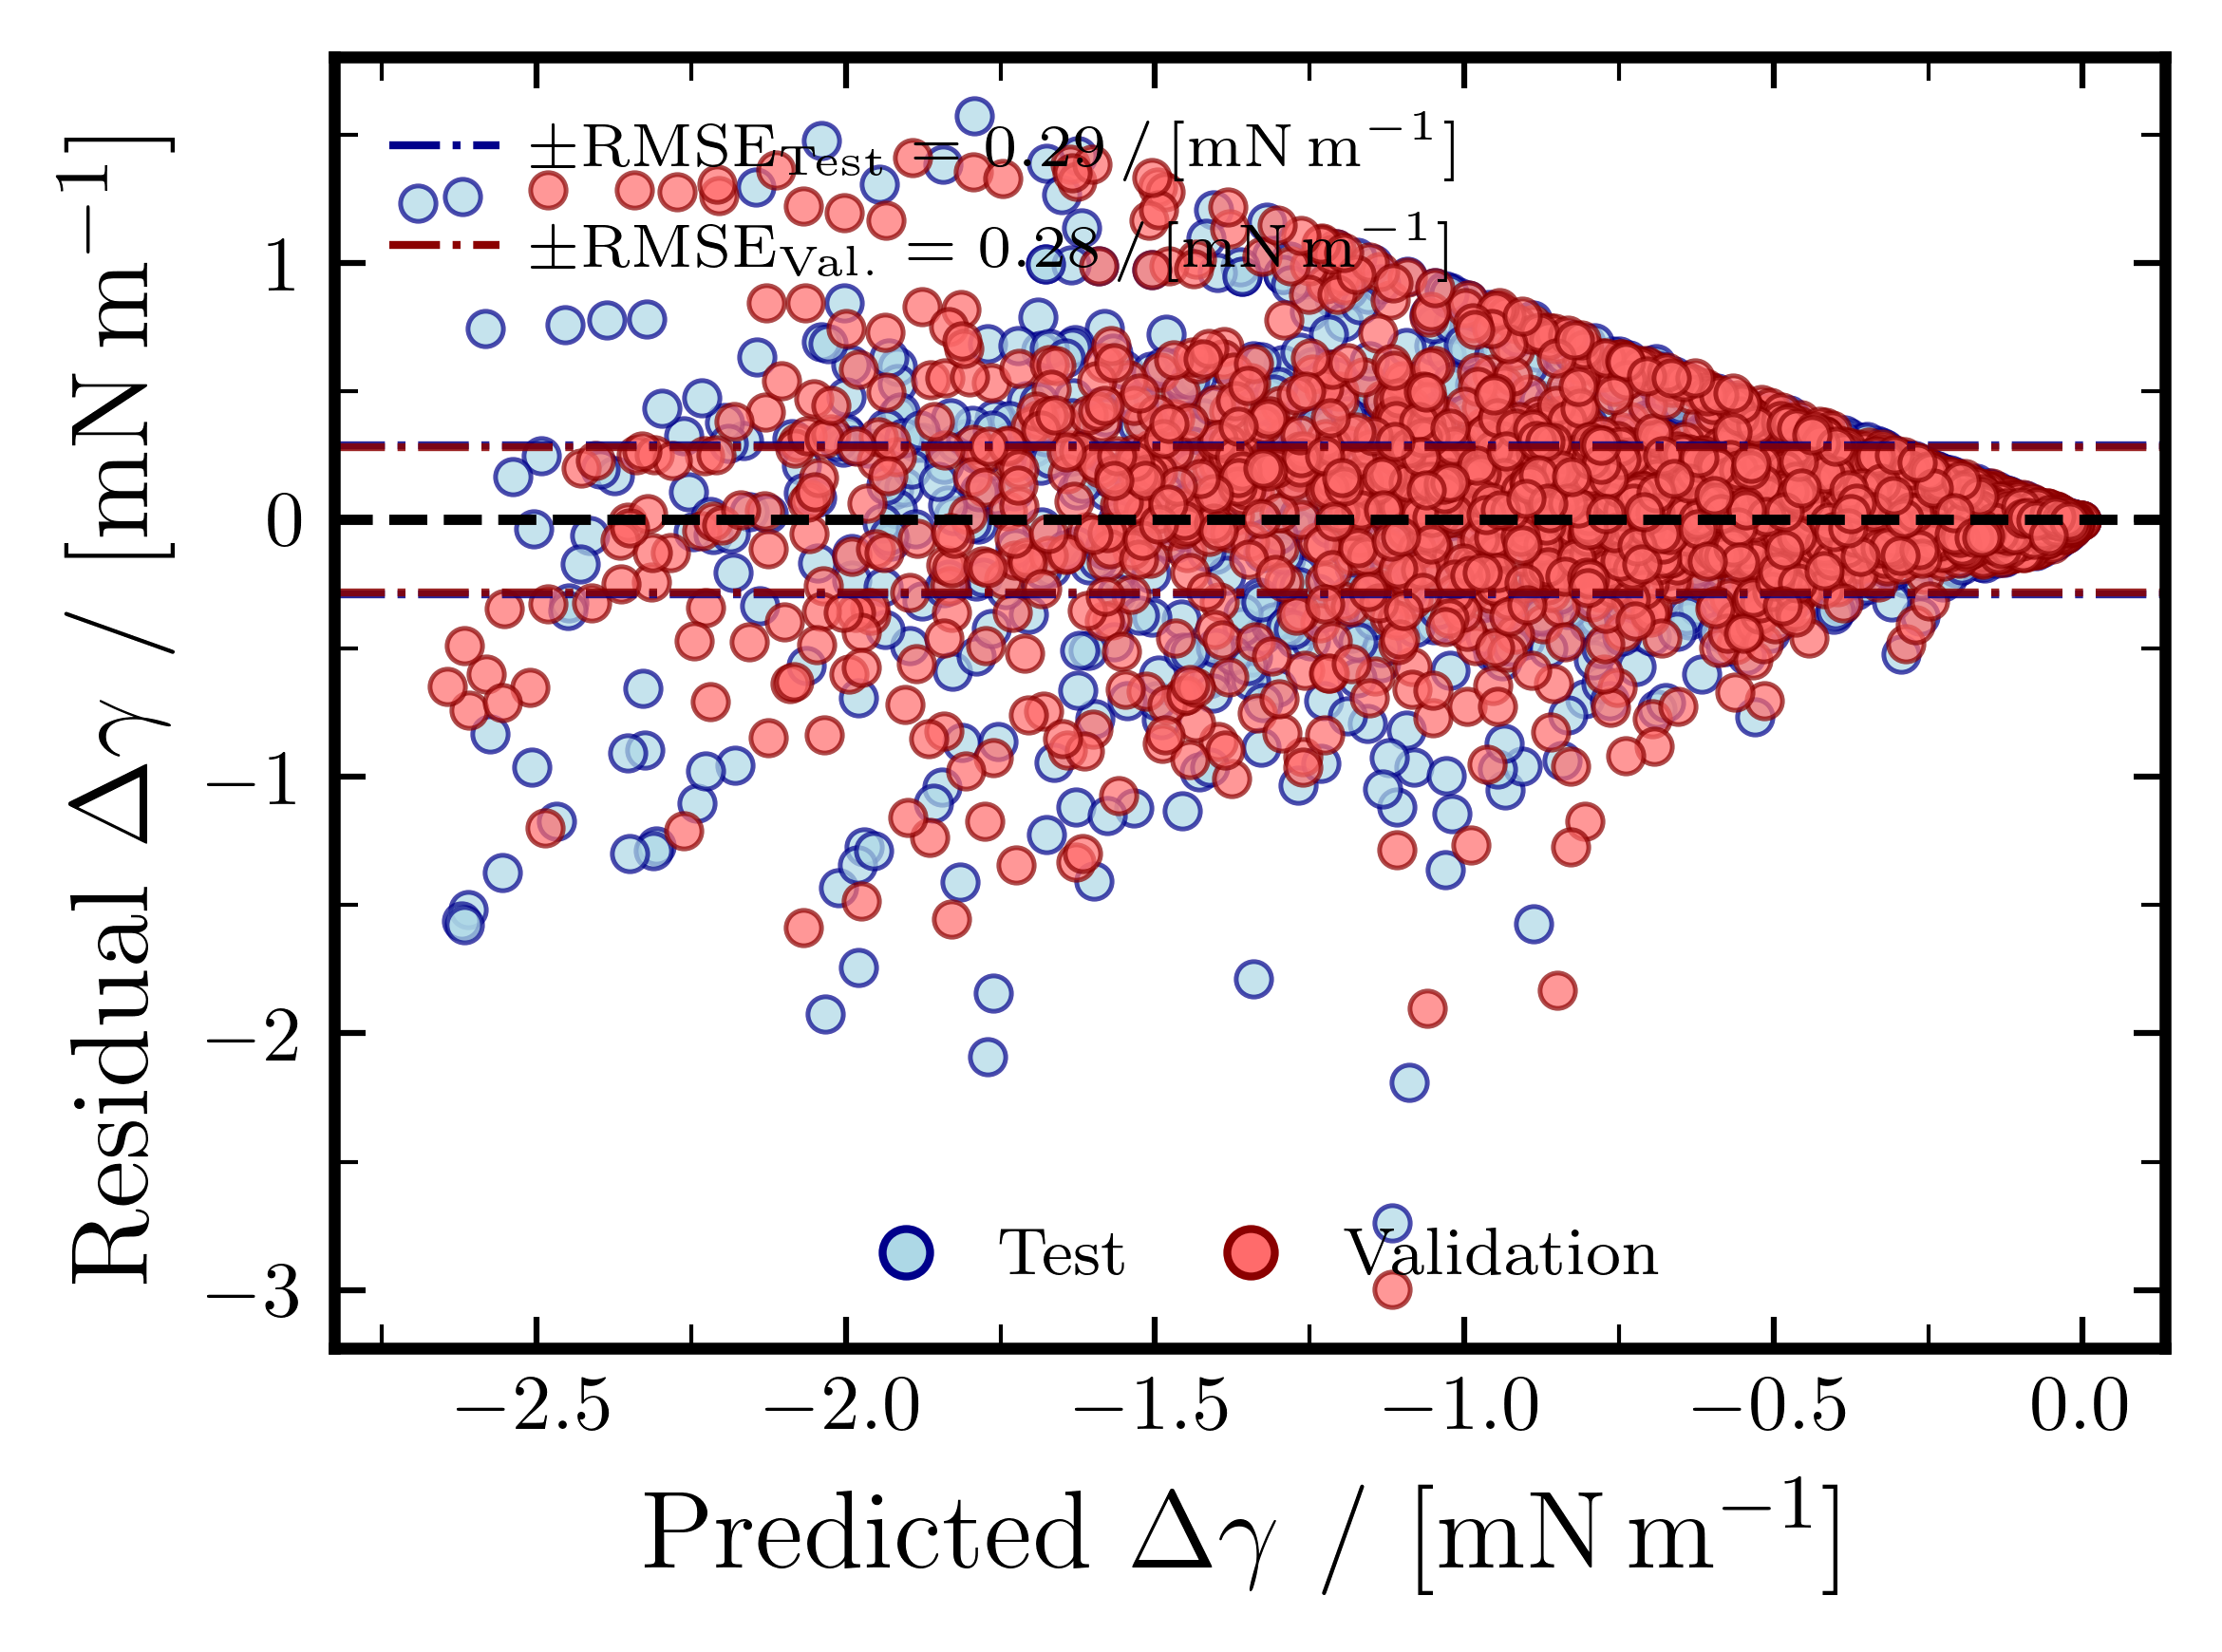

Saved: SR_parity_delta_gamma.(png|pdf), SR_residual_delta_gamma.(png|pdf) in /home/darshan/A6/PCSAFT_cDFT/PART_1/RESIDUAL/SR/Mixtures/SR_MIXTURES_OUTPUTS_V2


In [9]:
if "delta_gamma" in data_all:
    make_plots("delta_gamma", data_all["delta_gamma"])
else:
    print("Skipped: 'delta_gamma' target unavailable in current CSVs.")

## ε_base (SR's direct dimensionless target) — parity + residual

Always available. Useful for evaluating the SR equation on its native quantity.


=== eps_base : parity ===


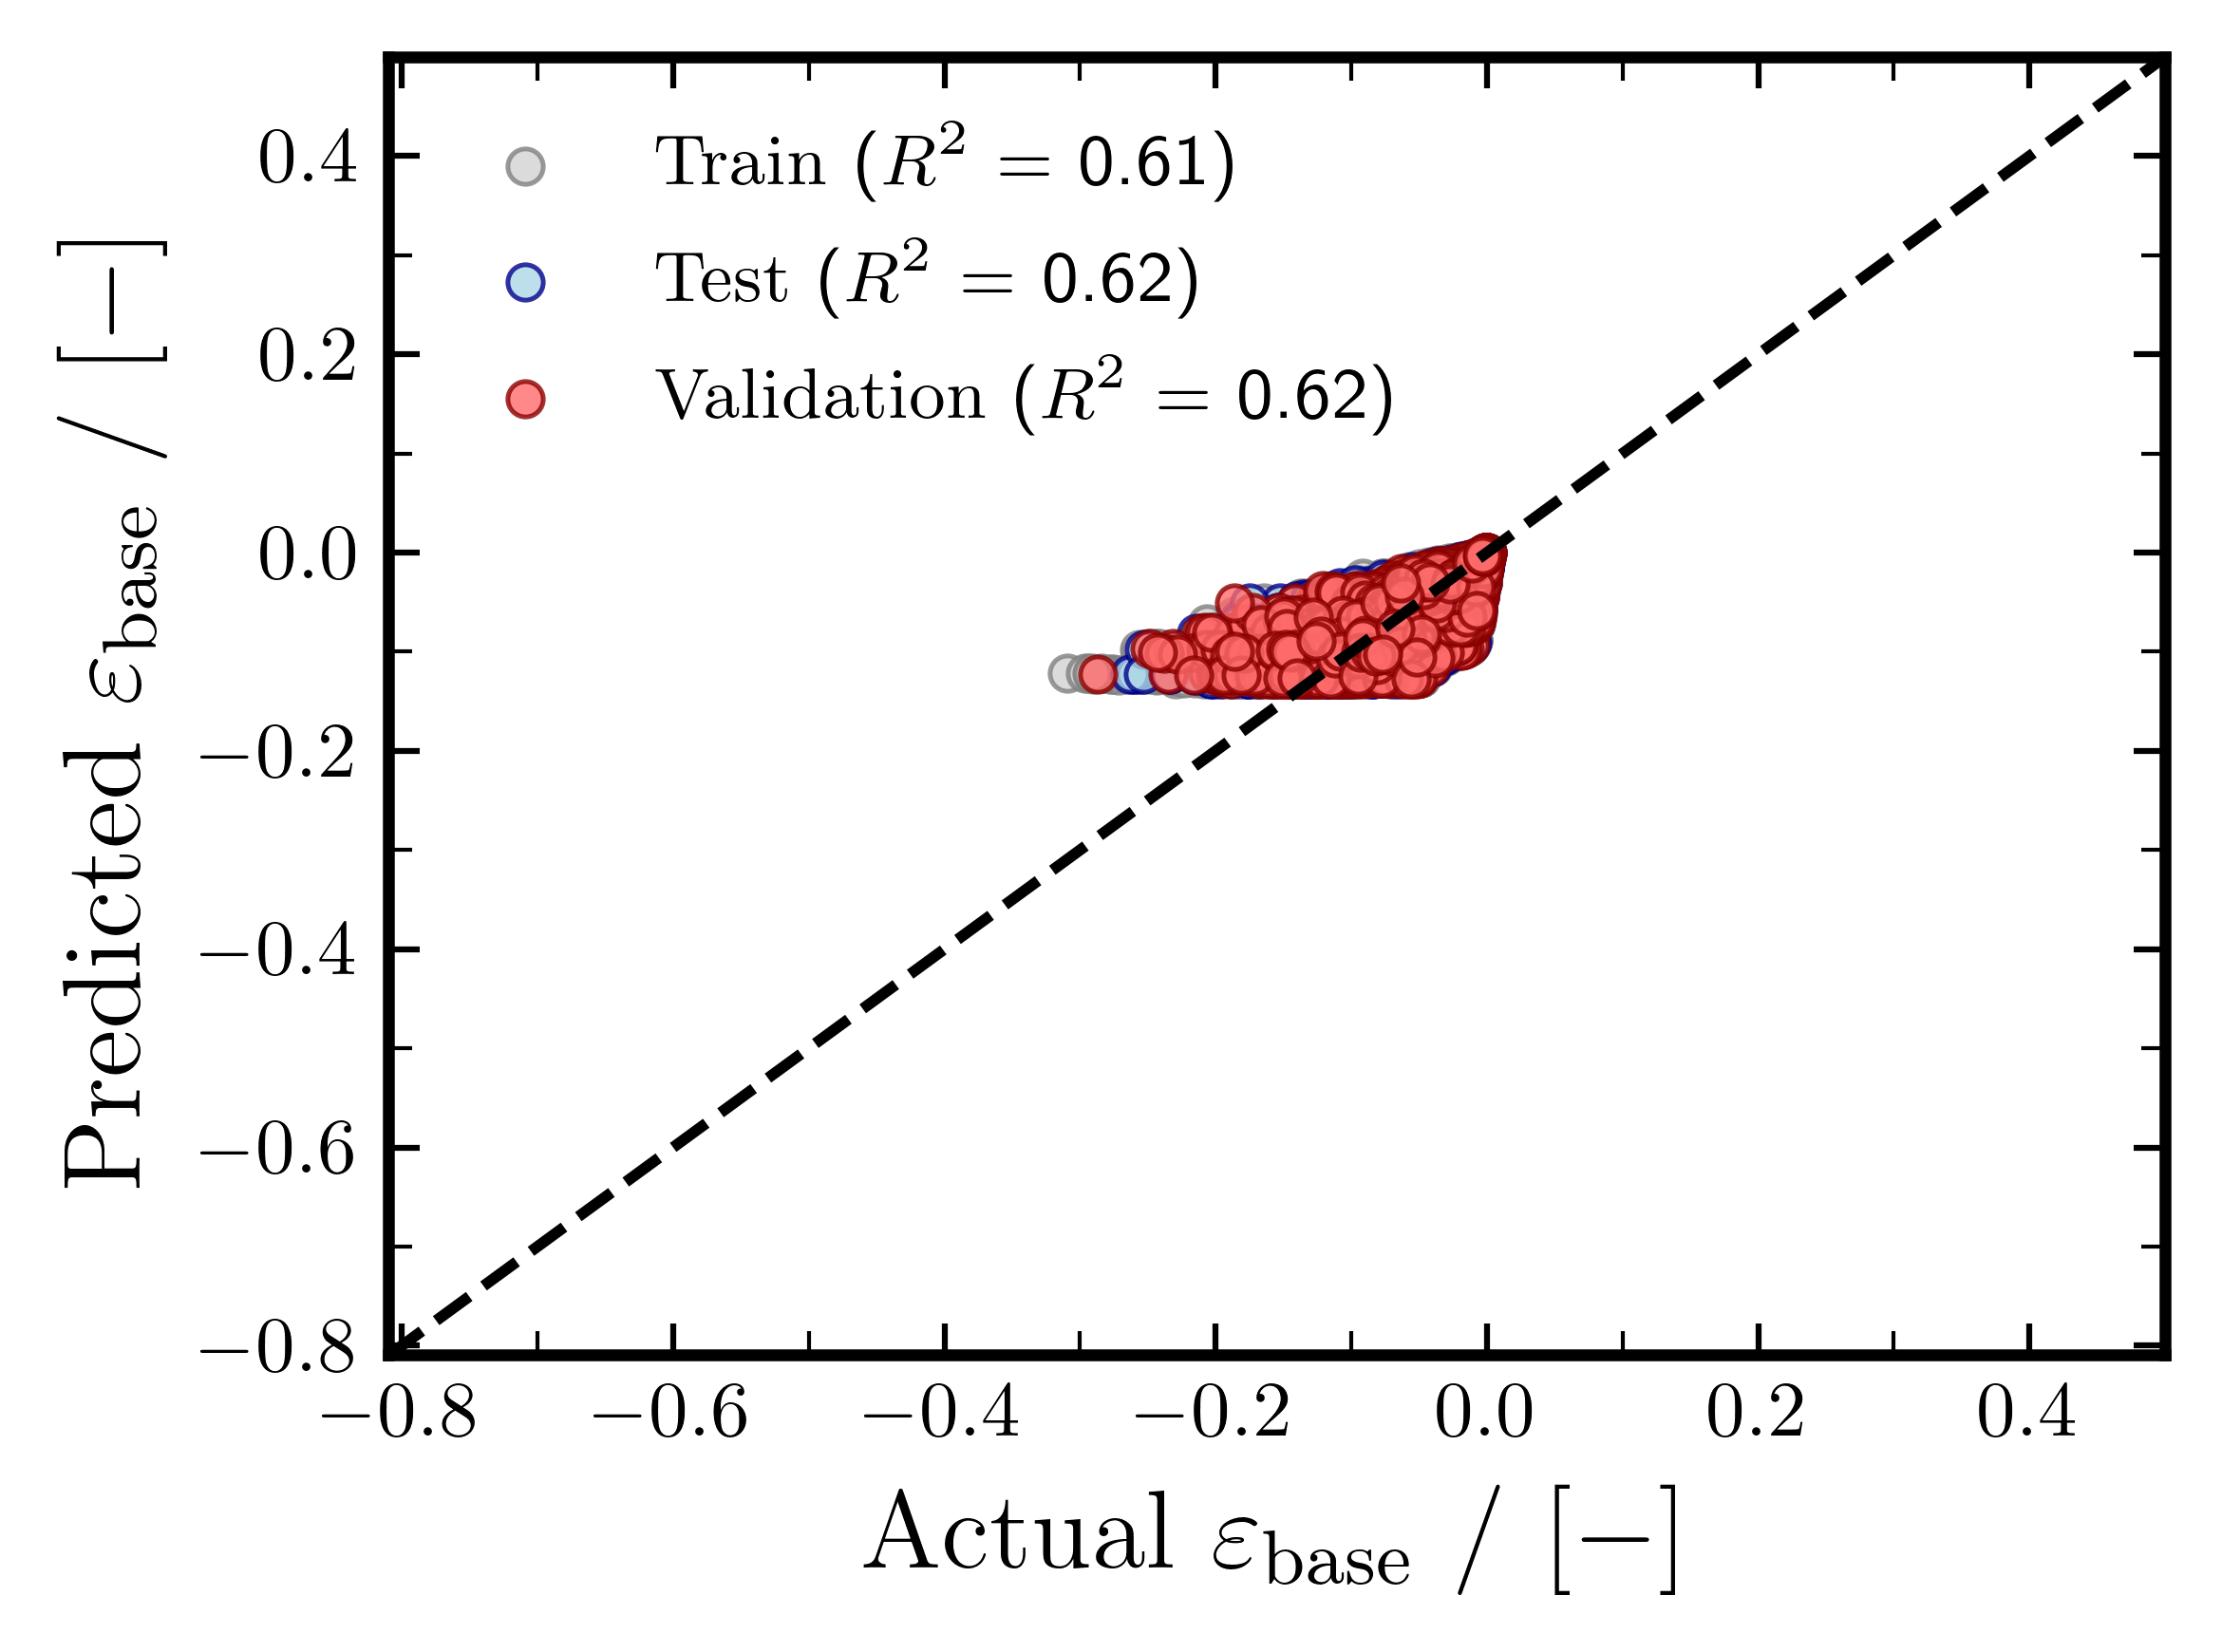

=== eps_base : residual ===


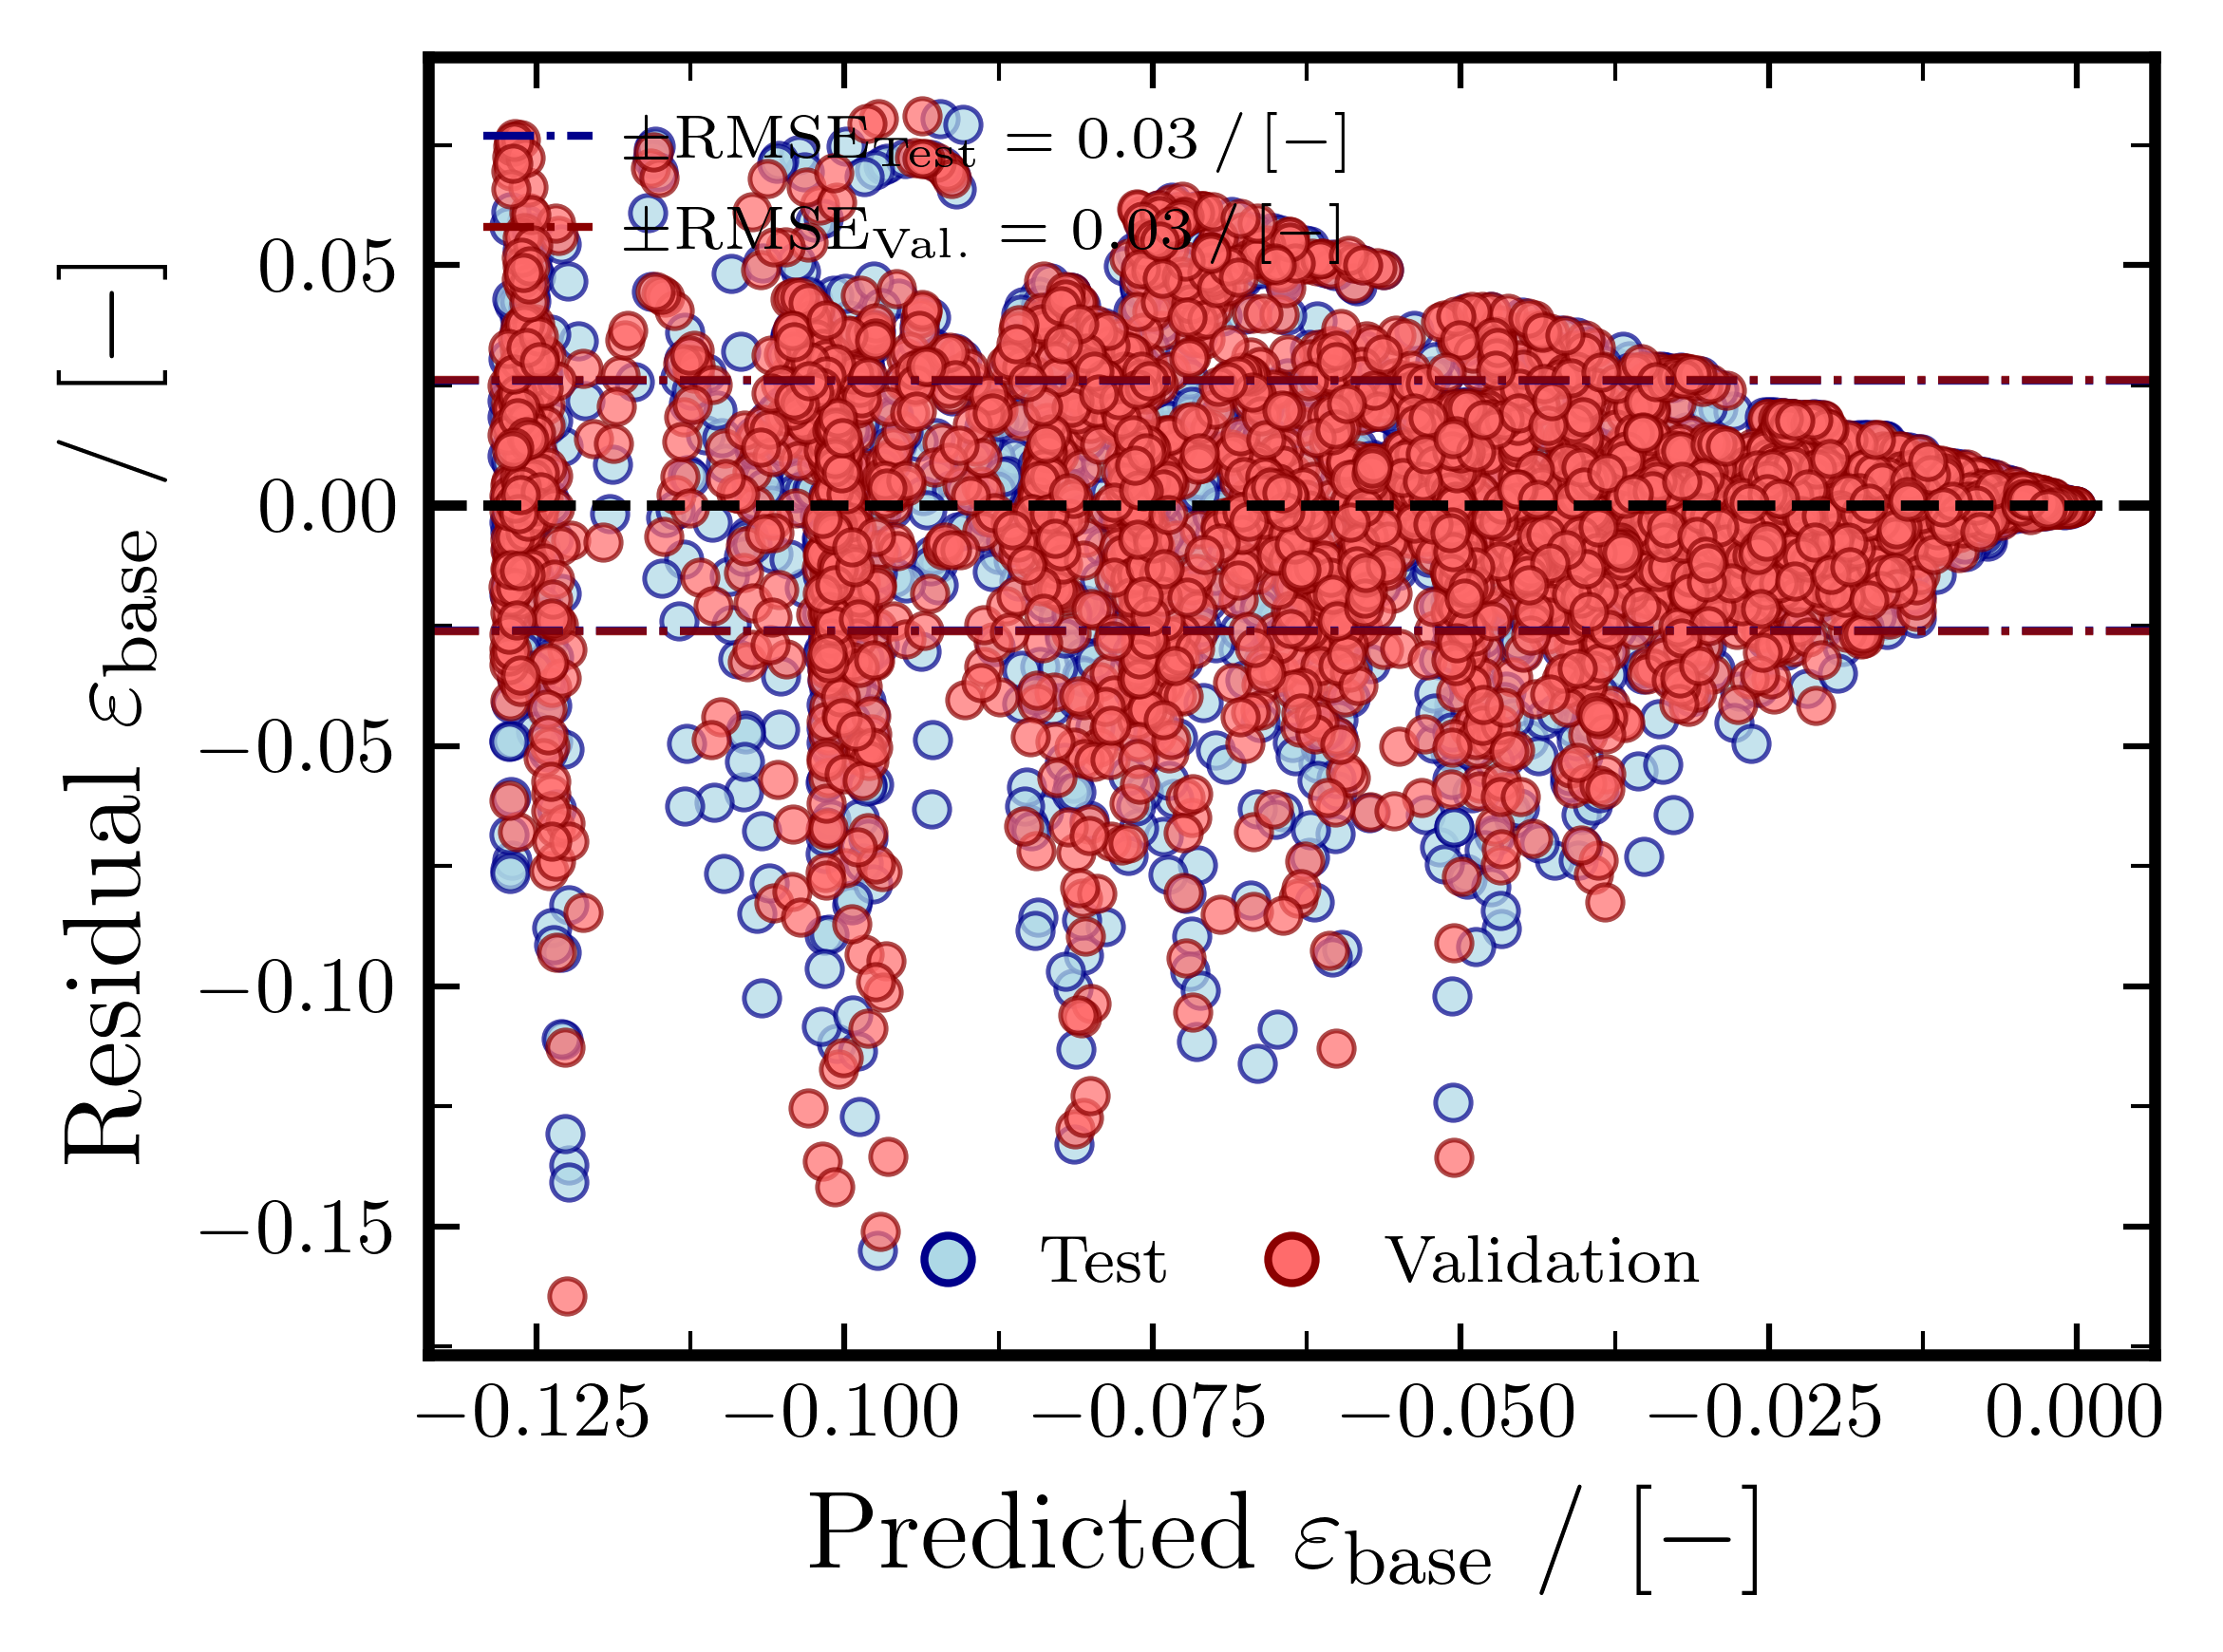

Saved: SR_parity_eps_base.(png|pdf), SR_residual_eps_base.(png|pdf) in /home/darshan/A6/PCSAFT_cDFT/PART_1/RESIDUAL/SR/Mixtures/SR_MIXTURES_OUTPUTS_V2


In [10]:
if "eps_base" in data_all:
    make_plots("eps_base", data_all["eps_base"])
else:
    print("Skipped: 'eps_base' target unavailable (Actual/Predicted columns missing).")

## Summary metrics

In [11]:
print(f"Targets plotted: {TARGETS_ACTUAL}\n")
for tgt in TARGETS_ACTUAL:
    print(f"--- {tgt} ---")
    for s in ("train", "val", "test"):
        a, p = data_all[tgt][s]
        print(f"  {s:5s}  RMSE = {rmse(a, p):.4g}   R² = {r2(a, p):.4f}   n = {len(a)}")
    print()

Targets plotted: ['gamma', 'delta_gamma', 'eps_base']

--- gamma ---
  train  RMSE = 0.2874   R² = 0.9977   n = 16130
  val    RMSE = 0.2824   R² = 0.9978   n = 3456
  test   RMSE = 0.2891   R² = 0.9976   n = 3457

--- delta_gamma ---
  train  RMSE = 0.2874   R² = 0.7450   n = 16130
  val    RMSE = 0.2824   R² = 0.7492   n = 3456
  test   RMSE = 0.2891   R² = 0.7531   n = 3457

--- eps_base ---
  train  RMSE = 0.027   R² = 0.6069   n = 16130
  val    RMSE = 0.02612   R² = 0.6207   n = 3456
  test   RMSE = 0.02599   R² = 0.6181   n = 3457

